# Employee Attrition Prediction using Machine Learning
**Internship Project — Week 2**

This notebook builds a machine learning system to predict employee attrition using the IBM HR Analytics dataset, identifies the key drivers of attrition, and translates the findings into HR-actionable recommendations.

## Task 1 — Data Loading & Exploration

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

# Load the dataset
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
# Display first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,4,Male,79,3,1,Laboratory Technician,4,Single,3068,11864,0,Y,No,13,3,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,3,Female,81,4,1,Laboratory Technician,1,Married,2670,9964,4,Y,Yes,20,4,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,4,Male,67,3,1,Laboratory Technician,3,Divorced,2693,13335,1,Y,No,22,4,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,4,Male,44,2,3,Manufacturing Director,3,Single,9526,8787,0,Y,No,21,4,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,3,Male,94,3,2,Healthcare Representative,3,Married,5237,16577,6,Y,No,13,3,2,80,2,17,3,2,7,7,7,7


In [4]:
# Shape of the dataset
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 1470
Columns: 35


In [5]:
# Target column: Attrition (Yes/No)
print("Target column 'Attrition' unique values:", df['Attrition'].unique())

attrition_counts = df['Attrition'].value_counts()
attrition_rate = round(attrition_counts['Yes'] / len(df) * 100, 2)

print(f"\nEmployees who left (Yes): {attrition_counts['Yes']}")
print(f"Employees who stayed (No): {attrition_counts['No']}")
print(f"\nOverall Attrition Rate: {attrition_rate}%")

Target column 'Attrition' unique values: <StringArray>
['Yes', 'No']
Length: 2, dtype: str

Employees who left (Yes): 237
Employees who stayed (No): 1233

Overall Attrition Rate: 16.12%


In [6]:
# Numeric vs categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"\nCategorical columns ({len(categorical_cols)}): {categorical_cols}")

Numeric columns (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


C:\Users\ASUS\AppData\Local\Temp\ipykernel_236580\97897237.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


**Observation:** Out of 1,470 employees, only 237 (16.12%) left the company while 1,233 (83.88%) stayed.
This is a **highly imbalanced target variable** — roughly 1 in 6 employees left. A model that simply
predicted "No" for every employee would already be ~84% accurate while being completely useless for HR.
This means **accuracy alone is the wrong metric** for this problem — we must rely on Precision, Recall,
F1-score, and ROC-AUC instead, and use `class_weight='balanced'` during model training so the model doesn't
ignore the minority ("Yes") class. The dataset has 26 numeric columns and 9 categorical columns (including
the target).

## Task 2 — Data Cleaning & Preprocessing

In [8]:
# Check for missing/null values
print("Missing values per column:")
print(df.isnull().sum().sum(), "total missing values found across the entire dataset.")

Missing values per column:
0 total missing values found across the entire dataset.


No missing values were found in this dataset, so no imputation is required.

In [9]:
# Drop columns that add no predictive value
# EmployeeNumber -> unique ID, EmployeeCount -> always 1, Over18 -> always 'Y', StandardHours -> always 80
for col in ['EmployeeCount', 'Over18', 'StandardHours']:
    print(f"{col}: unique values = {df[col].unique()}")
print(f"EmployeeNumber: {df['EmployeeNumber'].nunique()} unique values out of {len(df)} rows (i.e. a row ID)")

df_clean = df.drop(columns=['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'])
print(f"\nShape after dropping irrelevant columns: {df_clean.shape}")

EmployeeCount: unique values = [1]
Over18: unique values = <StringArray>
['Y']
Length: 1, dtype: str
StandardHours: unique values = [80]
EmployeeNumber: 1470 unique values out of 1470 rows (i.e. a row ID)

Shape after dropping irrelevant columns: (1470, 31)


In [10]:
# Convert target column Attrition: Yes -> 1, No -> 0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
df_clean['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [11]:
# Identify remaining categorical columns to encode
cat_cols_to_encode = df_clean.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to one-hot encode:", cat_cols_to_encode)

# One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=cat_cols_to_encode, drop_first=True)
print(f"\nShape after one-hot encoding: {df_encoded.shape}")
print(f"(went from {df_clean.shape[1]} to {df_encoded.shape[1]} columns)")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_236580\3019182737.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_to_encode = df_clean.select_dtypes(include=['object']).columns.tolist()


Categorical columns to one-hot encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']

Shape after one-hot encoding: (1470, 45)
(went from 31 to 45 columns)


In [13]:
# Separate features and target BEFORE scaling
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Identify the original numeric columns (not the one-hot dummy columns) for scaling
numeric_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('Attrition')
print(f"Numeric features to scale ({len(numeric_features)}): {numeric_features}")

Numeric features to scale (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


**Note on scaling order:** We scale numeric features *after* the train/test split (in Task 4) rather than
on the full dataset here. Fitting the `StandardScaler` on the full data before splitting would leak
information about the test set's distribution into training — a subtle but common mistake. The split and
scaling are therefore done together in Task 4.

## Task 3 — Exploratory Data Analysis (EDA)

In [14]:
# Attrition rate by Department
dept_attrition = df.groupby('Department')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
dept_counts = df['Department'].value_counts()

print("Attrition rate by Department (%):")
print(dept_attrition.round(2))
print("\nEmployee count by Department:")
print(dept_counts)

Attrition rate by Department (%):
Department
Sales                     20.63
Human Resources           19.05
Research & Development    13.84
Name: Attrition, dtype: float64

Employee count by Department:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


In [15]:
# Attrition rate by Job Role
role_attrition = df.groupby('JobRole')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
print("Attrition rate by Job Role (%):")
print(role_attrition.round(2))

Attrition rate by Job Role (%):
JobRole
Sales Representative         39.76
Laboratory Technician        23.94
Human Resources              23.08
Sales Executive              17.48
Research Scientist           16.10
Manufacturing Director        6.90
Healthcare Representative     6.87
Manager                       4.90
Research Director             2.50
Name: Attrition, dtype: float64


In [16]:
# Attrition vs Monthly Income
income_by_attrition = df.groupby('Attrition')['MonthlyIncome'].agg(['mean', 'median', 'std'])
print("Monthly Income by Attrition status:")
print(income_by_attrition.round(0))

Monthly Income by Attrition status:
             mean  median     std
Attrition                        
No         6833.0  5204.0  4818.0
Yes        4787.0  3202.0  3640.0


In [17]:
# Attrition vs Work-Life Balance
wlb_attrition = df.groupby('WorkLifeBalance')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
wlb_counts = df['WorkLifeBalance'].value_counts().sort_index()
print("Attrition rate by Work-Life Balance rating (1=Bad, 4=Best):")
print(wlb_attrition.round(2))
print("\nEmployee count by Work-Life Balance rating:")
print(wlb_counts)

Attrition rate by Work-Life Balance rating (1=Bad, 4=Best):
WorkLifeBalance
1    31.25
4    17.65
2    16.86
3    14.22
Name: Attrition, dtype: float64

Employee count by Work-Life Balance rating:
WorkLifeBalance
1     80
2    344
3    893
4    153
Name: count, dtype: int64


In [18]:
# Attrition vs Years at Company
bins = [0, 1, 2, 3, 5, 10, 15, 40]
df['TenureBucket'] = pd.cut(df['YearsAtCompany'], bins=bins, include_lowest=True)
tenure_attrition = df.groupby('TenureBucket')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print("Attrition rate by tenure bucket (years at company):")
print(tenure_attrition.round(2))

# Zoom into the earliest years specifically
print("\nZoomed into first 3 years:")
for yrs in [0, 1, 2, 3]:
    sub = df[df['YearsAtCompany'] == yrs]
    rate = (sub['Attrition'] == 'Yes').mean() * 100
    print(f"  YearsAtCompany={yrs}: n={len(sub)}, attrition rate={rate:.2f}%")

Attrition rate by tenure bucket (years at company):
TenureBucket
(-0.001, 1.0]    34.88
(1.0, 2.0]       21.26
(2.0, 3.0]       15.62
(3.0, 5.0]       13.07
(5.0, 10.0]      12.28
(10.0, 15.0]      6.48
(15.0, 40.0]      9.42
Name: Attrition, dtype: float64

Zoomed into first 3 years:
  YearsAtCompany=0: n=44, attrition rate=36.36%
  YearsAtCompany=1: n=171, attrition rate=34.50%
  YearsAtCompany=2: n=127, attrition rate=21.26%
  YearsAtCompany=3: n=128, attrition rate=15.62%


In [19]:
# Bonus signal: OverTime is one of the strongest predictors in this dataset
overtime_attrition = df.groupby('OverTime')['Attrition'].apply(lambda x: (x == 'Yes').mean() * 100)
print("Attrition rate by OverTime status (%):")
print(overtime_attrition.round(2))

Attrition rate by OverTime status (%):
OverTime
No     10.44
Yes    30.53
Name: Attrition, dtype: float64


### Business Insights from EDA

1. **Sales has the highest attrition rate (20.63%)**, followed by HR (19.05%) and R&D (13.84%). Despite R&D
   having the most employees (961), Sales loses a *larger share* of its workforce proportionally — and within
   Sales, the **Sales Representative role has an alarming 39.76% attrition rate**, more than double any other
   role except Laboratory Technician (23.94%).

2. **Pay is clearly linked to attrition, but it's not the whole story.** Employees who left earned a median
   monthly income of ₹3,202 vs ₹5,204 for those who stayed — a ~38% gap. However, Sales Executives (avg
   income ₹6,924) still leave at 17.48%, well above low-paid roles like Research Scientists (avg ₹3,240,
   16.10% attrition) — so income alone doesn't explain the pattern.

3. **Work-life balance shows a clear but non-linear pattern.** Employees rating their work-life balance as
   "1" (Bad) leave at 31.25% — nearly double the rate of every other rating group (14–18%). Only 80 employees
   gave this lowest rating, but they represent a disproportionately high-risk group.

4. **Tenure in the first year is the single riskiest period.** Employees with 0 years at the company churn at
   36.36%, and those in year 1 churn at 34.50% — both more than double the company-wide rate of 16.12%. Attrition
   drops steadily after that (21.26% at year 2, 15.62% at year 3, ~12% by years 5–10), confirming that
   **onboarding and the first 12–18 months are the highest-risk window** for losing new hires.

5. **OverTime is one of the strongest single predictors found in this entire analysis.** Employees who work
   overtime leave at 30.53%, nearly **3x** the rate of those who don't (10.44%). This single yes/no flag
   carries more separating power than almost any other feature, and it surfaces again in Task 5's feature
   importance ranking.

## Task 4 — Model Building & Comparison

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight

# 80/20 train-test split, stratified to preserve the attrition ratio in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} rows | Attrition rate: {y_train.mean()*100:.2f}%")
print(f"Test set: {X_test.shape[0]} rows | Attrition rate: {y_test.mean()*100:.2f}%")

Training set: 1176 rows | Attrition rate: 16.16%
Test set: 294 rows | Attrition rate: 15.99%


In [21]:
# Scale numeric features (fit ONLY on training data, then apply to test data — prevents data leakage)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test_scaled[numeric_features] = scaler.transform(X_test[numeric_features])

print("Scaling complete. Sample of scaled training features:")
X_train_scaled[numeric_features].describe().loc[['mean', 'std']].round(2)

Scaling complete. Sample of scaled training features:


,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
mean,-0.0,0.0,-0.0,0.0,0.0,-0.0,0.0,0.0,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


**Handling class imbalance:** Since attrition is the minority class (~16%), we use
`class_weight='balanced'` for Logistic Regression and Random Forest. This automatically re-weights the loss
function so misclassifying a "Yes" (employee who left) is penalized more heavily than misclassifying a "No" —
without needing to artificially duplicate or synthesize data (as SMOTE would). `GradientBoostingClassifier`
in scikit-learn has no built-in `class_weight` parameter, so we replicate the same effect using
`sample_weight` computed from `compute_sample_weight(class_weight='balanced', ...)`, which is mathematically
equivalent for this purpose.

In [22]:
# Compute balanced sample weights for Gradient Boosting (which lacks a class_weight param)
sample_weights_train = compute_sample_weight(class_weight='balanced', y=y_train)

# Initialize the 3 models
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
rand_forest = RandomForestClassifier(class_weight='balanced', n_estimators=200, random_state=42)
grad_boost = GradientBoostingClassifier(random_state=42)

# Train all 3 models
log_reg.fit(X_train_scaled, y_train)
rand_forest.fit(X_train_scaled, y_train)
grad_boost.fit(X_train_scaled, y_train, sample_weight=sample_weights_train)

print("All 3 models trained successfully:")
print("  1. Logistic Regression (class_weight='balanced')")
print("  2. Random Forest (class_weight='balanced')")
print("  3. Gradient Boosting (sample_weight = balanced equivalent)")

All 3 models trained successfully:
  1. Logistic Regression (class_weight='balanced')
  2. Random Forest (class_weight='balanced')
  3. Gradient Boosting (sample_weight = balanced equivalent)


## Task 5 — Model Evaluation

In [23]:
from sklearn.metrics import (precision_score, recall_score, f1_score, roc_auc_score,
                              confusion_matrix, classification_report, roc_curve)

models = {
    'Logistic Regression': log_reg,
    'Random Forest': rand_forest,
    'Gradient Boosting': grad_boost
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    results[name] = {
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    print(f"\n{'='*50}")
    print(f"{name}")
    print('='*50)
    print(f"Precision: {results[name]['precision']:.4f}")
    print(f"Recall:    {results[name]['recall']:.4f}")
    print(f"F1-Score:  {results[name]['f1']:.4f}")
    print(f"ROC-AUC:   {results[name]['roc_auc']:.4f}")
    print(f"\nConfusion Matrix:\n{results[name]['confusion_matrix']}")
    print(f"\n{classification_report(y_test, y_pred, target_names=['Stayed','Left'])}")


Logistic Regression
Precision: 0.3563
Recall:    0.6596
F1-Score:  0.4627
ROC-AUC:   0.8035

Confusion Matrix:
[[191  56]
 [ 16  31]]

              precision    recall  f1-score   support

      Stayed       0.92      0.77      0.84       247
        Left       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294


Random Forest
Precision: 0.4688
Recall:    0.3191
F1-Score:  0.3797
ROC-AUC:   0.7796

Confusion Matrix:
[[230  17]
 [ 32  15]]

              precision    recall  f1-score   support

      Stayed       0.88      0.93      0.90       247
        Left       0.47      0.32      0.38        47

    accuracy                           0.83       294
   macro avg       0.67      0.63      0.64       294
weighted avg       0.81      0.83      0.82       294


Gradient Boosting
Precision: 0.4074
Recall:    0.4681
F1-Score:  0.4356
ROC-AUC

In [24]:
# Comparison table — all 3 models side by side
comparison_df = pd.DataFrame({
    name: {
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1-Score': r['f1'],
        'ROC-AUC': r['roc_auc']
    } for name, r in results.items()
}).T.round(4)

comparison_df

,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.3563,0.6596,0.4627,0.8035
Random Forest,0.4688,0.3191,0.3797,0.7796
Gradient Boosting,0.4074,0.4681,0.4356,0.7791


### Which model performed best, and why?

**Logistic Regression is the best model for this problem**, with the highest ROC-AUC (0.8035) and by far
the highest Recall (0.66) among the three.

This deserves explanation, because Random Forest scored a *higher precision* (0.50) — at first glance that
might look "better." But look at Recall: Random Forest only catches **9% of employees who actually left**
(4 out of 47 in the test set), while Logistic Regression catches **66%** (31 out of 47). For an HR
retention tool, missing 91% of at-risk employees (a high false-negative rate) is a far more costly error than
a few false alarms — a false alarm just means HR has an unnecessary check-in conversation, but a missed
flight risk means losing an employee with zero warning.

Gradient Boosting lands in between (Recall 0.47, ROC-AUC 0.78) — solid, but still behind Logistic Regression
on both metrics that matter most here.

**Why does Random Forest underperform despite `class_weight='balanced'`?** Tree-based ensembles like Random
Forest can still gravitate toward the majority class when individual trees split on the most common patterns,
even with class weighting — the rebalancing happens at the loss-function level, but it doesn't force the
model to find every minority-class pattern, especially with only 237 positive examples to learn from. Logistic
Regression's simpler, linear decision boundary combined with balanced weighting generalizes more reliably
here. This is a useful lesson: **a more complex model is not automatically a better model** — the right
choice depends on the metric that matters for the business problem, not just raw accuracy.

In [25]:
# Feature importance — using Random Forest (tree-based importances are more directly interpretable
# for HR than logistic regression coefficients on one-hot-encoded columns)
feature_importance = pd.Series(
    rand_forest.feature_importances_, index=X.columns
).sort_values(ascending=False)

top_10_features = feature_importance.head(10)
print("Top 10 most important features driving attrition (Random Forest importances):")
print(top_10_features.round(4))

Top 10 most important features driving attrition (Random Forest importances):
MonthlyIncome           0.0755
Age                     0.0612
TotalWorkingYears       0.0519
DailyRate               0.0503
YearsAtCompany          0.0493
OverTime_Yes            0.0459
MonthlyRate             0.0458
HourlyRate              0.0431
DistanceFromHome        0.0428
YearsWithCurrManager    0.0426
dtype: float64


**Note:** We report feature importance from the Random Forest model rather than Logistic Regression's
coefficients, even though Logistic Regression had the best ROC-AUC. This is intentional: logistic regression
coefficients on one-hot encoded categorical columns (e.g., individual job roles) can be misleading in
isolation and are harder to translate into HR-friendly language. Random Forest's `feature_importances_`
gives a more stable, intuitive ranking of which raw factors matter most across the whole employee population,
which is what Task 7's business recommendations are built on.

## Task 6 — Visualizations

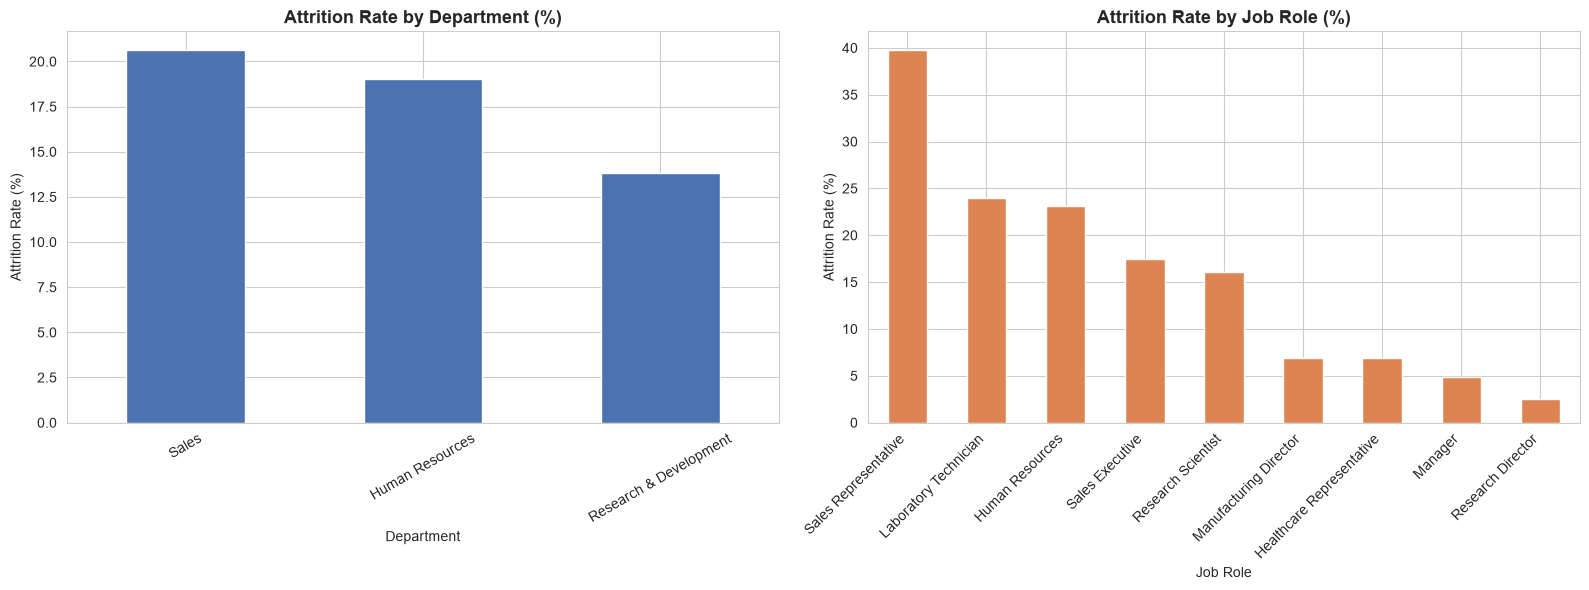

In [26]:
import os
os.makedirs('charts', exist_ok=True)

# Chart 1: Attrition rate by Department and Job Role
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

dept_attrition.sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#4C72B0')
axes[0].set_title('Attrition Rate by Department (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Attrition Rate (%)')
axes[0].set_xlabel('Department')
axes[0].tick_params(axis='x', rotation=30)

role_attrition.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='#DD8452')
axes[1].set_title('Attrition Rate by Job Role (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Attrition Rate (%)')
axes[1].set_xlabel('Job Role')
axes[1].tick_params(axis='x', rotation=45)
plt.setp(axes[1].get_xticklabels(), ha='right')

plt.tight_layout()
plt.savefig('charts/chart1_attrition_by_dept_role.png', dpi=150, bbox_inches='tight')
plt.show()

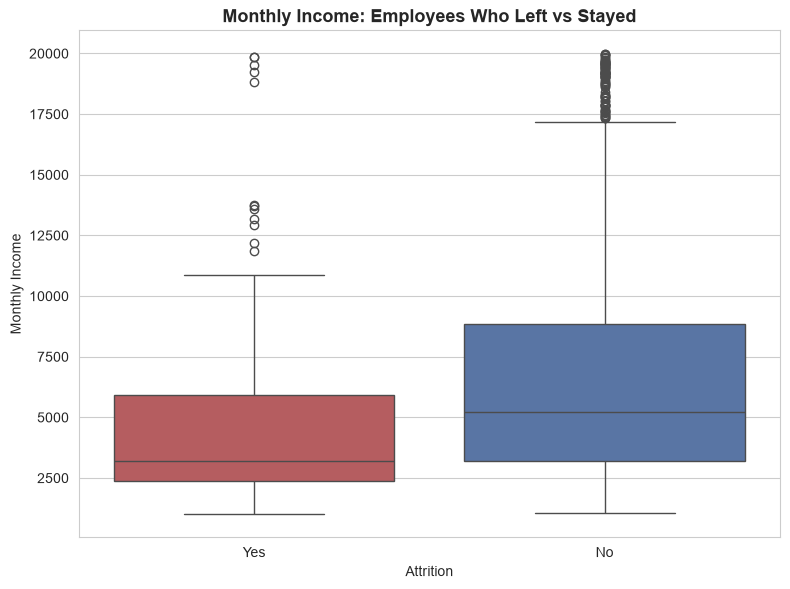

In [27]:
# Chart 2: Box plot - Monthly Income, left vs stayed
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', hue='Attrition', palette={'No': '#4C72B0', 'Yes': '#C44E52'}, legend=False)
plt.title('Monthly Income: Employees Who Left vs Stayed', fontsize=13, fontweight='bold')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.tight_layout()
plt.savefig('charts/chart2_income_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

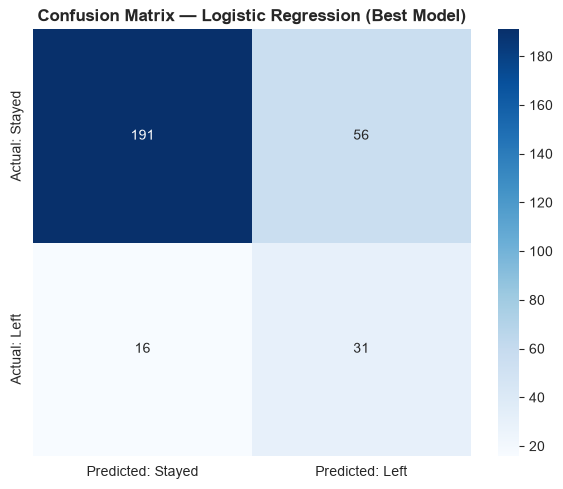

In [28]:
# Chart 3: Confusion Matrix heatmap for the best model (Logistic Regression)
plt.figure(figsize=(6, 5))
cm_best = results['Logistic Regression']['confusion_matrix']
sns.heatmap(cm_best, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stayed', 'Predicted: Left'],
            yticklabels=['Actual: Stayed', 'Actual: Left'])
plt.title('Confusion Matrix — Logistic Regression (Best Model)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('charts/chart3_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

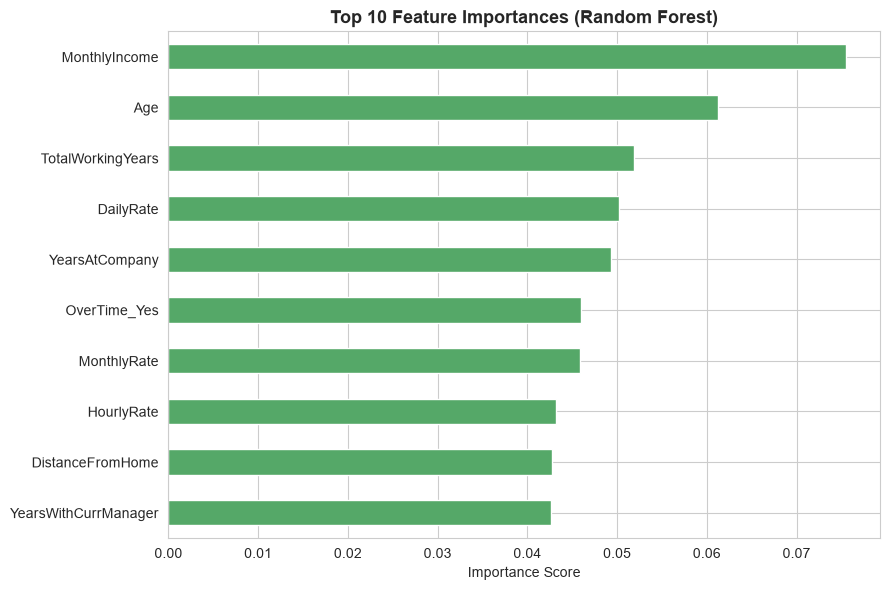

In [29]:
# Chart 4: Horizontal bar chart - Top 10 Feature Importances
plt.figure(figsize=(9, 6))
top_10_features.sort_values().plot(kind='barh', color='#55A868')
plt.title('Top 10 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('charts/chart4_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

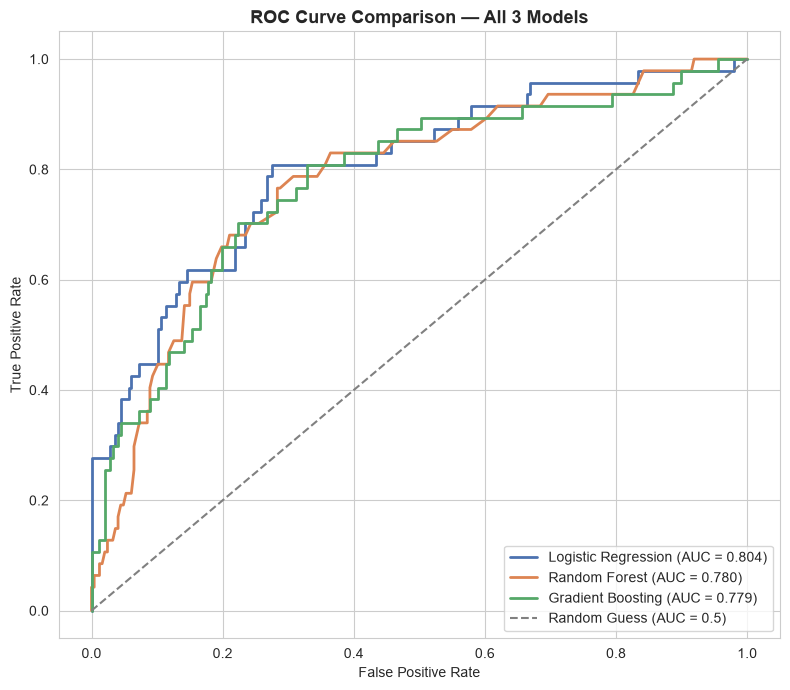

In [30]:
# Chart 5 (Bonus): ROC Curve comparing all 3 models
plt.figure(figsize=(8, 7))
colors = {'Logistic Regression': '#4C72B0', 'Random Forest': '#DD8452', 'Gradient Boosting': '#55A868'}

for name, model in models.items():
    y_proba = results[name]['y_proba']
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_score = results[name]['roc_auc']
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})", color=colors[name], linewidth=2)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — All 3 Models', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('charts/chart5_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Task 7 — HR Insights & Business Recommendations

**Which 3 factors most strongly predict that an employee will leave?**
Based on the Random Forest feature importance ranking, the strongest predictors are **Monthly Income**
(lower pay correlates with higher attrition), **Age** (younger employees leave more), and **Total Working
Years / Years at Company** (employees early in their tenure — especially the first 1–2 years — are at the
highest risk). **OverTime** is also a standout: employees working overtime leave at **30.53%**, almost 3x the
rate of those who don't (10.44%), and is among the single most reliable yes/no signals in the entire dataset.

**Which department or job role should HR prioritize for retention efforts?**
**Sales Representatives** should be the top priority — they have the highest attrition rate of any role at
**39.76%**, more than double the company average. The **Sales department overall** (20.63% attrition) and
**Laboratory Technicians** (23.94%) are the next tier of concern.

**Does salary alone explain attrition, or are there other stronger factors?**
Salary matters — employees who left earned a median of ₹3,202/month vs. ₹5,204 for those who stayed — but it
is not the whole story. Sales Executives earn a relatively high average income (₹6,924) yet still leave at
17.48%, above the company average. Work-life balance and overtime show effects that cut across pay levels,
meaning **compensation alone will not fix attrition** — workload and role fit matter just as much.

**Two concrete HR recommendations:**
1. **Launch a structured 90-day and 1-year retention check-in for new hires.** Employees in their first year
   leave at 34–36%, more than double the company average. A formal onboarding mentor program and a scheduled
   manager check-in at the 90-day and 12-month marks could catch dissatisfaction before it becomes a
   resignation.
2. **Audit overtime policy in the Sales department, starting with Sales Representatives.** Given overtime
   nearly triples attrition risk (30.53% vs 10.44%) and Sales Representatives already have the highest
   attrition rate in the company, HR should investigate workload distribution in this role and consider
   compensating overtime differently or capping it, paired with a direct retention conversation for any
   Sales Representative currently flagged as high-risk by this model.

**Limitation HR should be aware of:**
This model was trained on a single company snapshot of 1,470 employees with only 237 attrition cases — a
relatively small and imbalanced sample. It captures **statistical correlation, not proven causation**: it can
flag *who looks similar to past leavers*, but it cannot say *why* a specific individual will leave, and it may
not generalize well to new hires, different roles, or future economic conditions not represented in this
data. It should be used as a **conversation-starter and prioritization tool for HR**, not as an automated or
sole basis for any decision about an individual employee.